# Probe Analysis

Trains linear probes on hidden states to separate harmful from benign conversations.

**Design:**
- One logistic regression probe per turn position k
- Train on pair_ids 0–79, test on pair_ids 80–99 (held-out topics)
- Coverage check: skip turn k if fewer than 50 examples of either class
- Metrics: accuracy and AUC on held-out test set

**Visualizations:**
- PCA of all hidden states coloured by label
- Conversation trajectories through PCA space
- Probe accuracy and AUC across turn positions
- Probe score distributions by class

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.decomposition import PCA
from IPython.display import display

repo_root = Path("..").resolve()

# ── Config ────────────────────────────────────────────────────────────────────
FRAMEWORK = "actorattack"   # ← change to "crescendo" or "xteaming"

# Folders to load for this framework (harmful + benign)
FOLDERS = [
    f"{FRAMEWORK}_harmful_v2",
    f"{FRAMEWORK}_benign_v2",
]

REPR_ROOT = repo_root / "data" / "representations"

TRAIN_MAX_PAIR_ID = 79   # pairs 0–79 → train
TEST_MIN_PAIR_ID  = 80   # pairs 80–99 → test
MIN_EXAMPLES      = 50   # minimum per class to train a probe at turn k

print(f"Framework: {FRAMEWORK}")
print(f"Loading from: {FOLDERS}")

## 1. Load data

In [ ]:
states_list = []
meta_list   = []

for folder in FOLDERS:
    s_path = REPR_ROOT / folder / "hidden_states.npy"
    m_path = REPR_ROOT / folder / "metadata.parquet"
    if not s_path.exists():
        print(f"Missing: {s_path} — skipping")
        continue
    states_list.append(np.load(str(s_path)).astype(np.float32))
    meta_list.append(pd.read_parquet(m_path))
    print(f"Loaded {folder}: {states_list[-1].shape[0]} vectors")

states = np.concatenate(states_list, axis=0)
meta   = pd.concat(meta_list, ignore_index=True)

print(f"\nTotal vectors: {len(states)}")
print()
display(meta.groupby(["split", "verdict"])["turn_idx"].count().rename("n_vectors"))
print()
print("Vectors per turn position:")
display(meta.groupby(["split", "turn_idx"])["pair_id"].count().rename("n_vectors").unstack("split"))

## 2. PCA overview

Fit PCA on all vectors for this framework. Plot harmful vs benign in PC space.

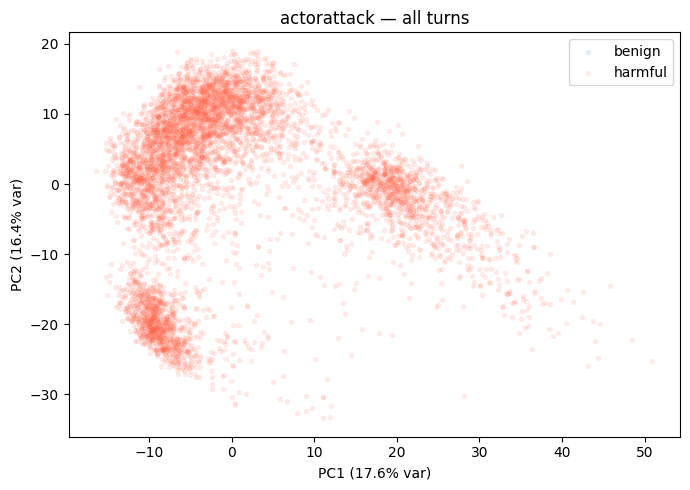

In [7]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(states)
meta["pc1"] = coords[:, 0]
meta["pc2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, color, name in [(0, "steelblue", "benign"), (1, "tomato", "harmful")]:
    m = meta["label"] == label
    ax.scatter(meta.loc[m, "pc1"], meta.loc[m, "pc2"],
               c=color, alpha=0.1, s=8, label=name, rasterized=True)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"{FRAMEWORK} — all turns")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Conversation trajectories

Each conversation as a path through PCA space: turn 1 → turn 2 → … → turn N.
Sample a subset of conversations to avoid overplotting.

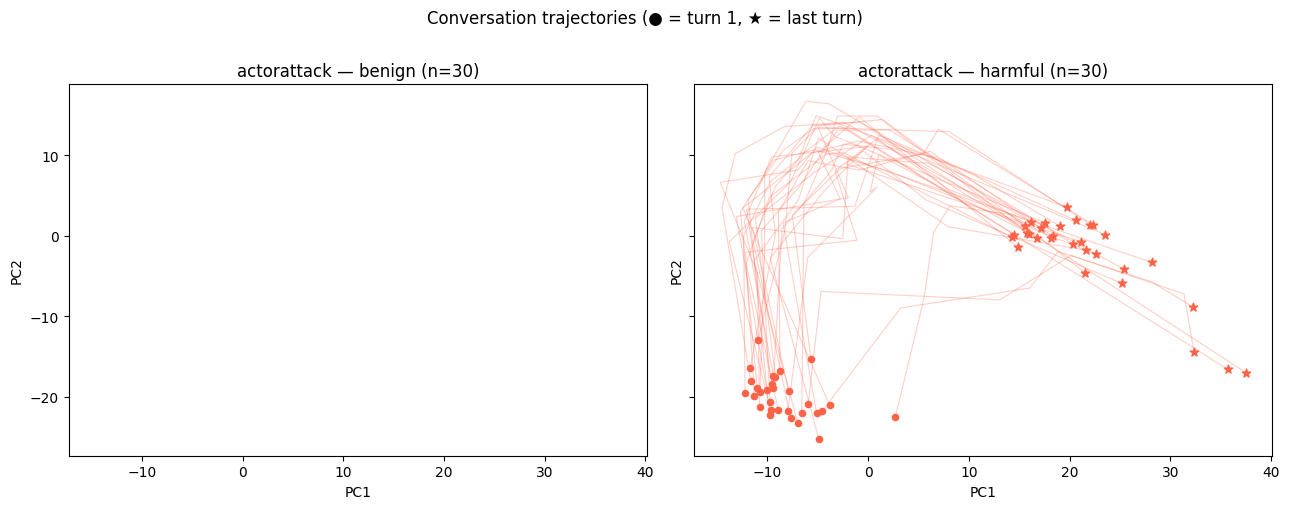

In [8]:
N_SAMPLE = 30   # conversations per class to plot

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, (split_name, label, color) in zip(axes, [("benign", 0, "steelblue"), ("harmful", 1, "tomato")]):
    split_meta = meta[meta["label"] == label]
    convs = split_meta[["pair_id", "attempt"]].drop_duplicates()
    sample = convs.sample(min(N_SAMPLE, len(convs)), random_state=42)

    for _, row in sample.iterrows():
        m = (split_meta["pair_id"] == row["pair_id"]) & (split_meta["attempt"] == row["attempt"])
        traj = split_meta[m].sort_values("turn_idx")
        if len(traj) < 2:
            continue
        ax.plot(traj["pc1"], traj["pc2"], color=color, alpha=0.3, linewidth=0.8)
        ax.scatter(traj["pc1"].iloc[0],  traj["pc2"].iloc[0],  color=color, s=20, zorder=3)
        ax.scatter(traj["pc1"].iloc[-1], traj["pc2"].iloc[-1], color=color, s=40, marker="*", zorder=4)

    ax.set_title(f"{FRAMEWORK} — {split_name} (n={N_SAMPLE})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Conversation trajectories (● = turn 1, ★ = last turn)", y=1.01)
plt.tight_layout()
plt.show()

## 4. Linear probes per turn position

Train one logistic regression per turn k on pair_ids 0–79, evaluate on 80–99.

In [ ]:
turn_positions = sorted(meta["turn_idx"].unique())
probe_results = []

for k in turn_positions:
    m = meta["turn_idx"] == k
    X_k = states[m]
    y_k = meta.loc[m, "label"].values
    pid  = meta.loc[m, "pair_id"].values

    train = pid <= TRAIN_MAX_PAIR_ID
    test  = pid >= TEST_MIN_PAIR_ID

    X_tr, y_tr = X_k[train], y_k[train]
    X_te, y_te = X_k[test],  y_k[test]

    # Coverage check
    if (y_tr == 0).sum() < MIN_EXAMPLES or (y_tr == 1).sum() < MIN_EXAMPLES:
        print(f"Turn {k}: skipped (train coverage too low)")
        continue
    if (y_te == 0).sum() < 5 or (y_te == 1).sum() < 5:
        print(f"Turn {k}: skipped (test coverage too low)")
        continue

    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(X_tr, y_tr)

    probs = clf.predict_proba(X_te)[:, 1]
    acc   = accuracy_score(y_te, clf.predict(X_te))
    auc   = roc_auc_score(y_te, probs)

    probe_results.append({"turn_idx": k, "accuracy": acc, "auc": auc,
                          "n_train": len(y_tr), "n_test": len(y_te), "clf": clf})
    print(f"Turn {k}: acc={acc:.3f}  AUC={auc:.3f}  (train={len(y_tr)}, test={len(y_te)})")

df_probes = pd.DataFrame([{k: v for k, v in r.items() if k != "clf"} for r in probe_results])
print()
display(df_probes)

## 5. Probe accuracy and AUC across turns

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ["accuracy", "auc"], ["Accuracy", "AUC"]):
    ax.plot(df_probes["turn_idx"], df_probes[metric], marker="o", color="steelblue")
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8, label="chance")
    ax.set_xlabel("Turn position")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{FRAMEWORK} — {ylabel} by turn")
    ax.set_ylim(0.4, 1.02)
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Probe score distributions by class

For each turn, plot the distribution of harmful probability scores for harmful vs benign conversations.

In [ ]:
n_probes = len(probe_results)
fig, axes = plt.subplots(1, n_probes, figsize=(4 * n_probes, 4), sharey=True)
if n_probes == 1:
    axes = [axes]

for ax, result in zip(axes, probe_results):
    k   = result["turn_idx"]
    clf = result["clf"]
    m   = (meta["turn_idx"] == k) & (meta["pair_id"] >= TEST_MIN_PAIR_ID)

    X_te = states[m]
    y_te = meta.loc[m, "label"].values
    probs = clf.predict_proba(X_te)[:, 1]

    for label, color, name in [(0, "steelblue", "benign"), (1, "tomato", "harmful")]:
        ax.hist(probs[y_te == label], bins=20, range=(0, 1),
                color=color, alpha=0.5, label=name, density=True)

    ax.set_title(f"Turn {k}  (AUC={result['auc']:.3f})")
    ax.set_xlabel("P(harmful)")
    if ax == axes[0]:
        ax.set_ylabel("Density")
        ax.legend()

plt.suptitle(f"{FRAMEWORK} — probe score distributions (test set)", y=1.02)
plt.tight_layout()
plt.show()

## 7. Mean probe score trajectory

Average P(harmful) across turns, separately for harmful and benign conversations.

In [ ]:
rows = []
for result in probe_results:
    k   = result["turn_idx"]
    clf = result["clf"]
    m   = (meta["turn_idx"] == k) & (meta["pair_id"] >= TEST_MIN_PAIR_ID)

    probs = clf.predict_proba(states[m])[:, 1]
    y     = meta.loc[m, "label"].values

    rows.append({"turn_idx": k, "split": "harmful", "mean_score": probs[y == 1].mean()})
    rows.append({"turn_idx": k, "split": "benign",  "mean_score": probs[y == 0].mean()})

df_traj = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
for split, color in [("harmful", "tomato"), ("benign", "steelblue")]:
    d = df_traj[df_traj["split"] == split]
    ax.plot(d["turn_idx"], d["mean_score"], marker="o", color=color, label=split)

ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8)
ax.set_xlabel("Turn position")
ax.set_ylabel("Mean P(harmful)")
ax.set_title(f"{FRAMEWORK} — mean probe score across turns (test set)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()